<a href="https://colab.research.google.com/github/ch4rliem/Carlos-Mendez-Callegne-TelecomX_LATAM-Part1/blob/main/TelecomX_LATAM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#📌 Extracción

In [12]:
import pandas as pd

In [13]:

df_telecom = pd.read_json('TelecomX_Data.json')

In [15]:
df_telecom.head()

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


In [17]:
df_telecom.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerID  7267 non-null   object
 1   Churn       7267 non-null   object
 2   customer    7267 non-null   object
 3   phone       7267 non-null   object
 4   internet    7267 non-null   object
 5   account     7267 non-null   object
dtypes: object(6)
memory usage: 340.8+ KB


#🔧 Transformación

In [18]:
# 1. Normalizar las columnas que tienen diccionarios anidados
df_customer = pd.json_normalize(df_telecom['customer'])
df_phone = pd.json_normalize(df_telecom['phone'])
df_internet = pd.json_normalize(df_telecom['internet'])
df_account = pd.json_normalize(df_telecom['account'])

# 2. Unir todo en un solo DataFrame limpio
# Concatenamos las nuevas columnas y eliminamos las originales anidadas
df_clean = pd.concat([df_telecom[['customerID', 'Churn']], df_customer, df_phone, df_internet, df_account], axis=1)

# 3. Ver el resultado
print("✅ Datos transformados y aplanados:")
df_clean.head()

✅ Datos transformados y aplanados:


,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


In [19]:
# Verificar si hay valores nulos en el nuevo DataFrame
print("Conteo de valores nulos por columna:")
print(df_clean.isnull().sum())

# Revisar los tipos de datos finales
print("\nTipos de datos de las columnas:")
df_clean.info()

Conteo de valores nulos por columna:
customerID          0
Churn               0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
Charges.Monthly     0
Charges.Total       0
dtype: int64

Tipos de datos de las columnas:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7267 non-null   object 
 1   Churn             7267 non-null   object 
 2   gender            7267 non-null   object 
 3   SeniorCitizen     7267 non-null   int64  
 4   Partner           7267 non-null   object 
 5   Dependents    

In [20]:
# 1. Convertir Charges.Total a numérico
# errors='coerce' transformará cualquier espacio vacío o texto inválido en NaN (nulo)
df_clean['Charges.Total'] = pd.to_numeric(df_clean['Charges.Total'], errors='coerce')

# 2. Verificar si surgieron nulos tras la conversión
print(f"Nulos encontrados en Charges.Total tras la conversión: {df_clean['Charges.Total'].isnull().sum()}")

# 3. Si hay nulos (clientes nuevos con 0 cargos), los llenamos con 0 o con el valor de Charges.Monthly
df_clean['Charges.Total'] = df_clean['Charges.Total'].fillna(0)

# 4. Verificamos los tipos finales
print("\nTipos de datos actualizados:")
print(df_clean[['Charges.Monthly', 'Charges.Total']].dtypes)

Nulos encontrados en Charges.Total tras la conversión: 11

Tipos de datos actualizados:
Charges.Monthly    float64
Charges.Total      float64
dtype: object


#📊 Carga y análisis

Distribución de Churn:
Churn
No     5174
Yes    1869
        224
Name: count, dtype: int64


/tmp/ipykernel_259/1341023088.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y='Charges.Monthly', data=df_clean, palette='magma')


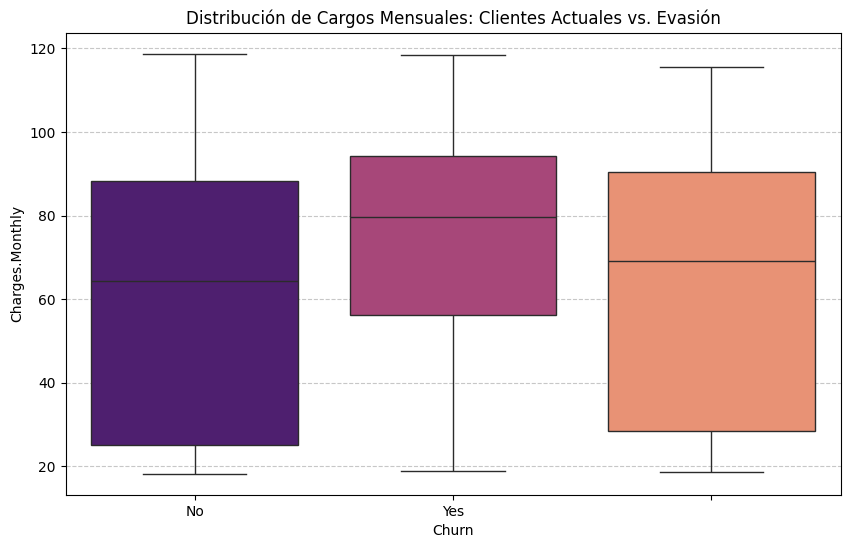


💰 La pérdida acumulada por evasión de clientes es de: $2,862,926.90


In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. ¿Cuántos clientes se han ido realmente?
print("Distribución de Churn:")
print(df_clean['Churn'].value_counts())

# 2. Análisis del impacto financiero (Cargos Mensuales)
plt.figure(figsize=(10, 6))
sns.boxplot(x='Churn', y='Charges.Monthly', data=df_clean, palette='magma')
plt.title('Distribución de Cargos Mensuales: Clientes Actuales vs. Evasión')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# 3. Cálculo de pérdida total (TotalCharges de los que marcaron "Yes")
pérdida_total = df_clean[df_clean['Churn'] == 'Yes']['Charges.Total'].sum()
print(f"\n💰 La pérdida acumulada por evasión de clientes es de: ${pérdida_total:,.2f}")

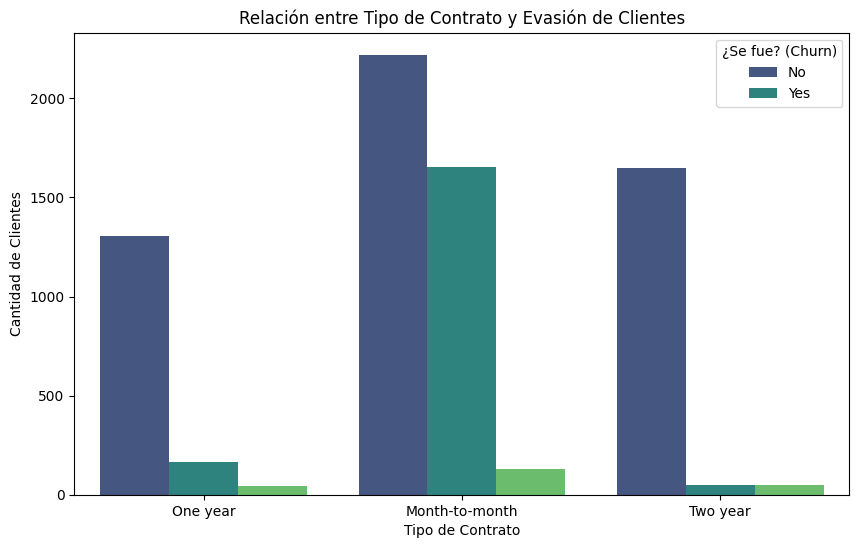

Porcentaje de Churn por tipo de contrato:
Churn                            No        Yes
Contract                                      
Month-to-month  3.245943  55.430712  41.323346
One year        3.028308  86.043450  10.928242
Two year        2.753873  94.492255   2.753873


In [22]:
# Crear un gráfico de barras apiladas para ver la relación Churn vs Contrato
plt.figure(figsize=(10, 6))
sns.countplot(x='Contract', hue='Churn', data=df_clean, palette='viridis')

plt.title('Relación entre Tipo de Contrato y Evasión de Clientes')
plt.xlabel('Tipo de Contrato')
plt.ylabel('Cantidad de Clientes')
plt.legend(title='¿Se fue? (Churn)')
plt.show()

# Ver los porcentajes exactos
print("Porcentaje de Churn por tipo de contrato:")
print(pd.crosstab(df_clean['Contract'], df_clean['Churn'], normalize='index') * 100)

In [24]:
# 1. Eliminar filas donde 'Churn' no sea 'Yes' o 'No' (limpiar los 224 vacíos)
df_final = df_clean[df_clean['Churn'].isin(['Yes', 'No'])].copy()

# 2. Verificar que ahora solo tengamos dos categorías
print("Nueva distribución de Churn:")
print(df_final['Churn'].value_counts())

# 3. Guardar el progreso
# Esto es útil por si quieres descargar el CSV limpio después
df_final.to_csv('TelecomX_Data_Clean.csv', index=False)
print("\n✅ Dataset filtrado y guardado como 'TelecomX_Data_Clean.csv'")

Nueva distribución de Churn:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

✅ Dataset filtrado y guardado como 'TelecomX_Data_Clean.csv'


In [30]:
# Crear la columna de cuentas diarias (Gasto promedio por mes de antigüedad)
# Usamos max(tenure, 1) para evitar dividir por cero en clientes nuevos
df_final['Daily_Charges'] = df_final['Charges.Total'] / df_final['tenure'].replace(0, 1)

print("✅ Columna 'Daily_Charges' creada exitosamente.")
df_final[['customerID', 'tenure', 'Charges.Total', 'Daily_Charges']].head()

✅ Columna 'Daily_Charges' creada exitosamente.


,customerID,tenure,Charges.Total,Daily_Charges
0,0002-ORFBO,9,593.30,65.922222
1,0003-MKNFE,9,542.40,60.266667
2,0004-TLHLJ,4,280.85,70.212500
3,0011-IGKFF,13,1237.85,95.219231
4,0013-EXCHZ,3,267.40,89.133333


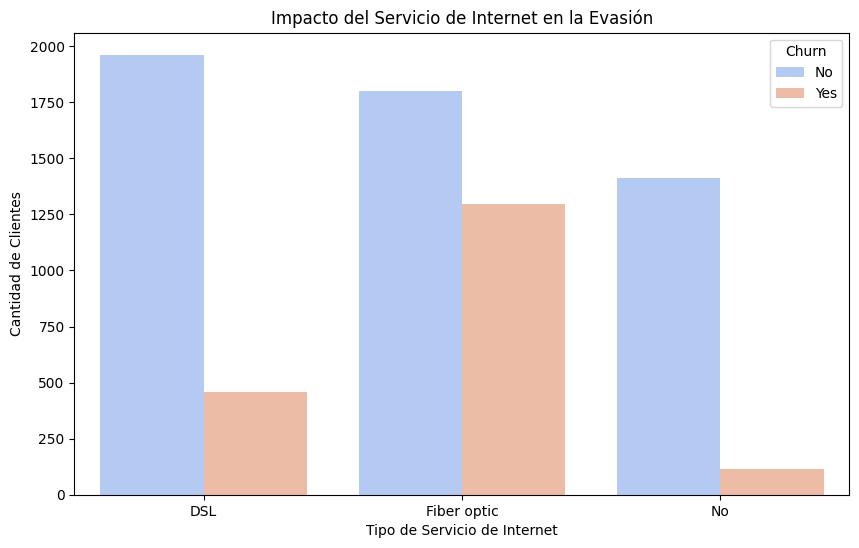

Tasa de Churn por servicio:
Churn                   No        Yes
InternetService                      
DSL              81.040892  18.959108
Fiber optic      58.107235  41.892765
No               92.595020   7.404980


In [25]:
# Comparar Churn por tipo de servicio de internet
plt.figure(figsize=(10, 6))
sns.countplot(x='InternetService', hue='Churn', data=df_final, palette='coolwarm')

plt.title('Impacto del Servicio de Internet en la Evasión')
plt.xlabel('Tipo de Servicio de Internet')
plt.ylabel('Cantidad de Clientes')
plt.show()

# Ver la tasa de Churn porcentual
print("Tasa de Churn por servicio:")
print(pd.crosstab(df_final['InternetService'], df_final['Churn'], normalize='index') * 100)

Código para "Recuento por Variables Categóricas"

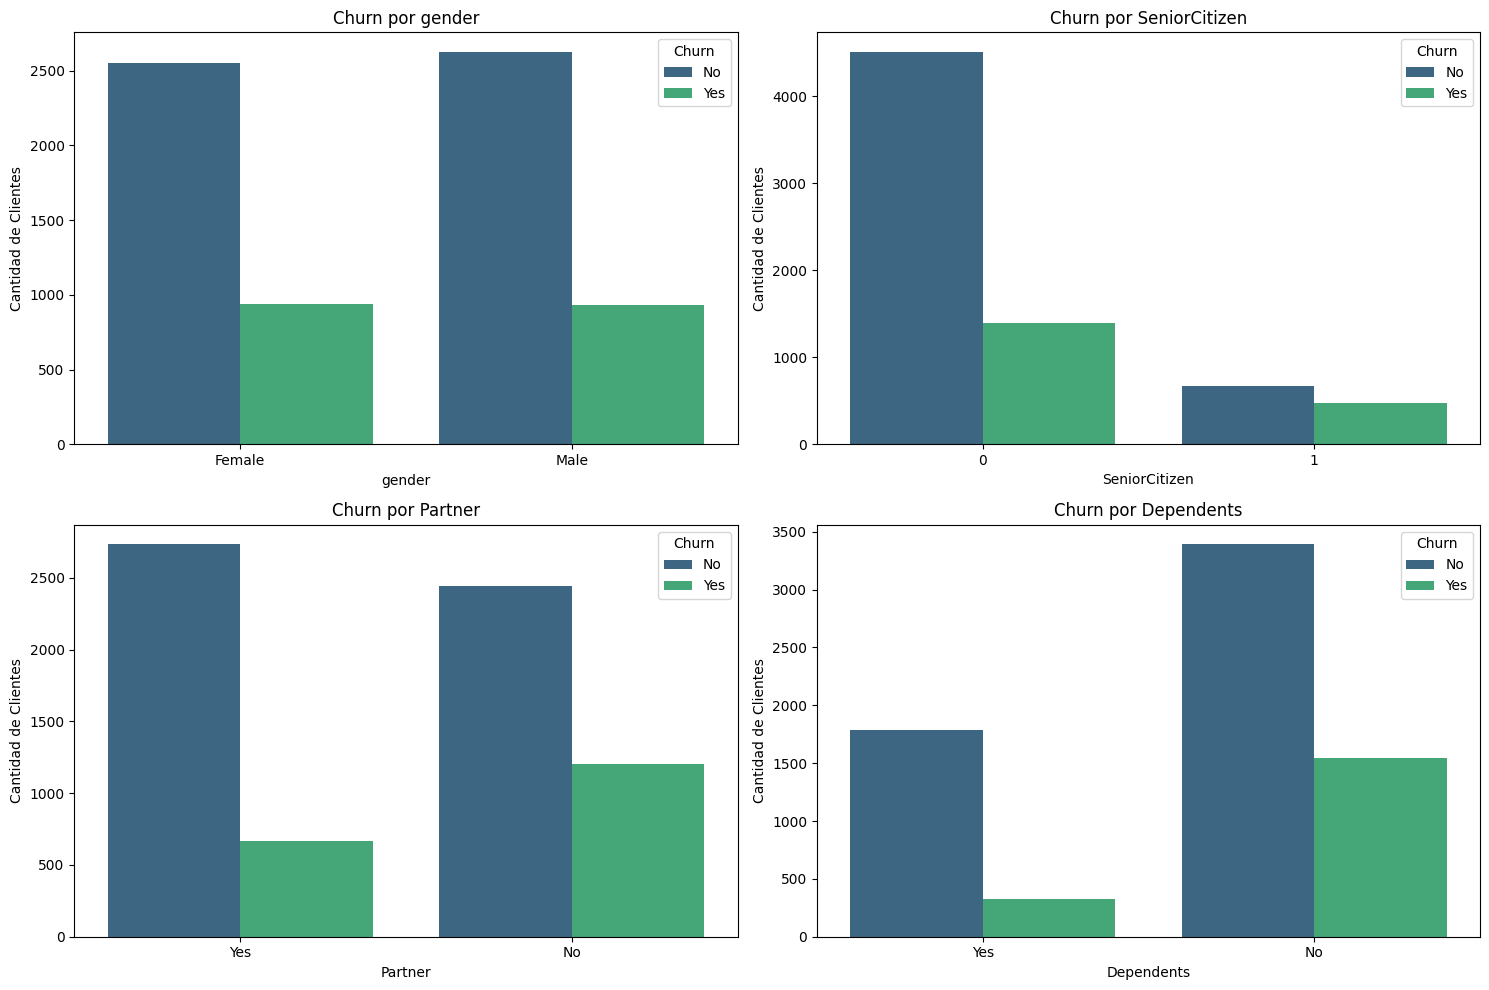

Proporción de Churn en Ciudadanos Mayores (1 = Sí, 0 = No):
Churn                 No        Yes
SeniorCitizen                      
0              76.393832  23.606168
1              58.318739  41.681261


In [27]:
# Lista de variables demográficas a analizar
cols_demograficas = ['gender', 'SeniorCitizen', 'Partner', 'Dependents']

plt.figure(figsize=(15, 10))

for i, col in enumerate(cols_demograficas, 1):
    plt.subplot(2, 2, i)
    sns.countplot(x=col, hue='Churn', data=df_final, palette='viridis')
    plt.title(f'Churn por {col}')
    plt.xlabel(col)
    plt.ylabel('Cantidad de Clientes')

plt.tight_layout()
plt.show()

# Ver las proporciones exactas para SeniorCitizen (Suele ser un punto crítico)
print("Proporción de Churn en Ciudadanos Mayores (1 = Sí, 0 = No):")
print(pd.crosstab(df_final['SeniorCitizen'], df_final['Churn'], normalize='index') * 100)

In [28]:
# Estadísticas de las variables numéricas para clientes que se van vs los que se quedan
print("Resumen estadístico de cargos mensuales por Churn:")
display(df_final.groupby('Churn')['Charges.Monthly'].describe())

print("\nResumen estadístico de antigüedad (tenure) por Churn:")
display(df_final.groupby('Churn')['tenure'].describe())

Resumen estadístico de cargos mensuales por Churn:


,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5174.0,61.265124,31.092648,18.25,25.10,64.425,88.4,118.75
Yes,1869.0,74.441332,24.666053,18.85,56.15,79.650,94.2,118.35



Resumen estadístico de antigüedad (tenure) por Churn:


,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5174.0,37.569965,24.113777,0.0,15.0,38.0,61.0,72.0
Yes,1869.0,17.979133,19.531123,1.0,2.0,10.0,29.0,72.0


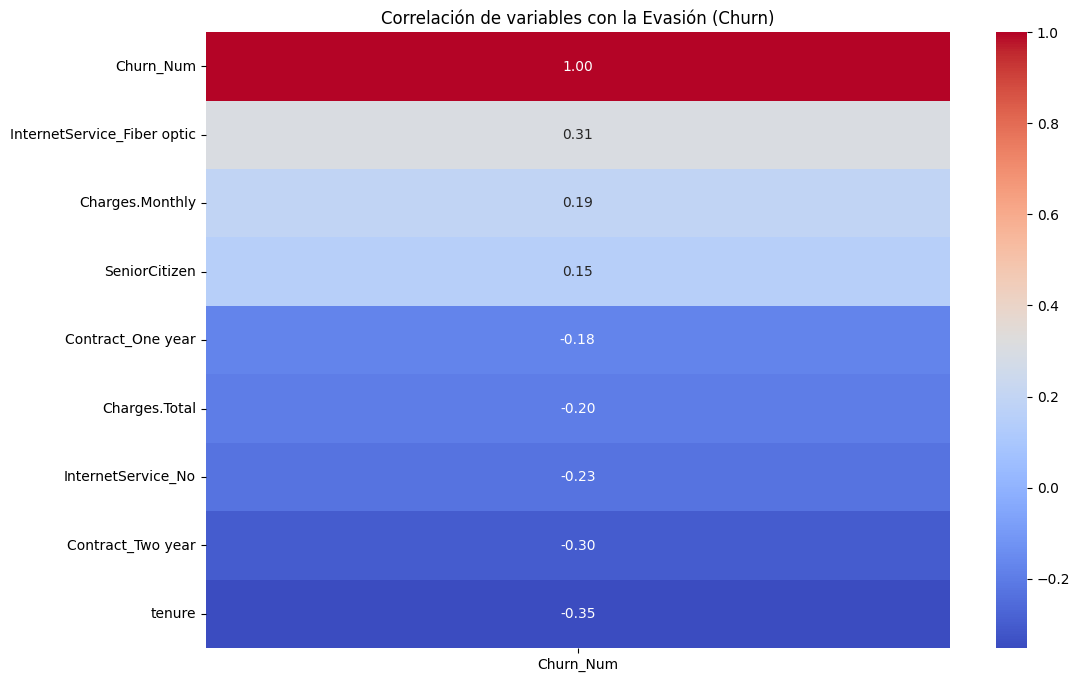

In [29]:
# 1. Preparar una copia numérica para la correlación
df_corr = df_final.copy()
df_corr['Churn_Num'] = df_corr['Churn'].map({'Yes': 1, 'No': 0})

# 2. Seleccionar variables clave (puedes añadir más si quieres)
# Convertimos Contract y InternetService a variables dummy para medirlas
df_corr = pd.get_dummies(df_corr, columns=['Contract', 'InternetService'], drop_first=True)

# 3. Calcular la correlación con respecto al Churn
plt.figure(figsize=(12, 8))
correlaciones = df_corr.corr(numeric_only=True)[['Churn_Num']].sort_values(by='Churn_Num', ascending=False)

sns.heatmap(correlaciones, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlación de variables con la Evasión (Churn)')
plt.show()

#📄Informe final

# 📢 Informe Ejecutivo: Análisis de Evasión (Telecom X)

## 🎯 Hallazgos Principales
1. **Riesgo por Tecnología**: Los clientes de **Fibra Óptica** tienen una tasa de evasión del **41.8%**, siendo el principal foco rojo técnico.
2. **Impacto del Contrato**: El contrato **Mes a Mes** es el mayor predictor de fuga. Los contratos a largo plazo (1-2 años) reducen la evasión a menos del 3%.
3. **Perfil Crítico**: Los clientes que se van pagan, en promedio, **$13 USD más al mes** que los que se quedan, lo que maximiza el impacto financiero.

## 💰 Impacto Financiero
* **Pérdida Total Identificada**: $2,862,926.90 USD.

## 🚀 Recomendaciones
* **Fidelización**: Incentivar la migración de contratos mensuales a anuales mediante descuentos progresivos.
* **Calidad Técnica**: Investigar la estabilidad del servicio de Fibra Óptica, ya que presenta una correlación positiva atípica con la fuga de clientes.